# Лабораторная работа: Моделирование хаотических систем, анализ устойчивости
 


## Информация  
---
> ФИО_1, ИСУ_1:  
> 
> ФИО_2, ИСУ_2:  
>
> ФИО_3, ИСУ_3:  
---


Исследовать прикладное использование хаотических динамических систем и уравнений в частных производных (УРЧП) для генерации криптографических ключей и защищенной передачи данных. Закрепить навыки использования функций Ляпунова для анализа устойчивости ошибок синхронизации.


В этой работе вы будете использовать следующие библиотеки Python:

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import hashlib

# Первая часть

## Вступление

В данной работе будут рассмотрены **хаотические системы** — класс нелинейных динамических систем, демонстрирующих крайне высокую чувствительность к начальным условиям (так называемый «эффект бабочки»). Это означает, что даже малое изменение начальных параметров приведет к совершенно отличному от исходного поведению системы. Несмотря на видимую хаотичность и кажущуюся случайность, такие системы полностью детерминированы.

Классическим примером хаотической системы является **система Лоренца**, представляющая собой упрощенную математическую модель конвекции в атмосфере. Она записывается в виде системы трех обыкновенных дифференциальных уравнений:
$$
\begin{cases}
\dot{x} = \sigma (y - x), \\
\dot{y} = x (\rho - z) - y, \\
\dot{z} = x y - \beta z,
\end{cases}
$$
где:
- $x, y, z$ — переменные состояния системы,
- $\sigma$ (число Прандтля), $\rho$ (число Рэлея) и $\beta$ — параметры системы. При определенных значениях этих параметров (традиционно $\sigma = 10$, $\rho = 28$, $\beta = 8/3$) система демонстрирует устойчивое хаотическое поведение и формирует знаменитый странный аттрактор Лоренца («бабочку»).

## Что нужно сделать

Используя классические параметры, решите систему с помощью `scipy.integrate.solve_ivp`. Постройте график в 3D пространстве. Выберите два очень близких начальных условия (например, отличающихся на $10^{-5}$ по одной из координат) и постройте графики $x(t)$ для обоих случаев на одной оси.


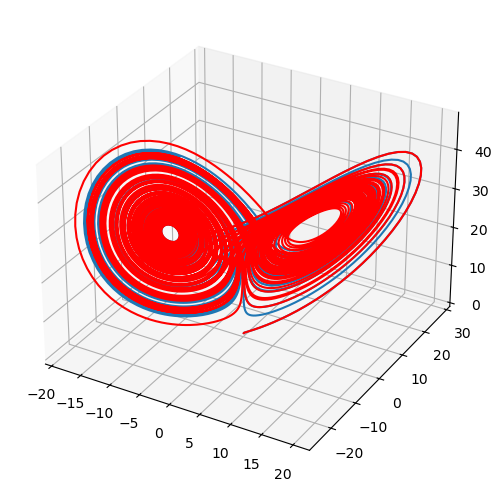

In [63]:
sigma = 10
rho = 28
beta = 8/3

def lorenz_system(t, state):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return [dx, dy, dz]

fig = plt.figure(figsize=(15, 5))

ax = fig.add_subplot(1, 2, 1, projection='3d')

t_max = 70 
t_eval = np.linspace(0, t_max, 10000)

sol1 = solve_ivp(lorenz_system, [0, t_max], [0.1 + 0.00001, 0, 0],  t_eval=t_eval, rtol=1e-9, atol=1e-9)
sol2 = solve_ivp(lorenz_system, [0, t_max], [0.1, 0, 0], t_eval=t_eval, rtol=1e-9, atol=1e-9)

X, Y, Z = sol1.y
X1, Y1, Z1 = sol2.y

ax.plot(X, Y, Z)
ax.plot(X1, Y1, Z1, color = "red")

plt.tight_layout()
plt.show()

---
> ❗ **Вопрос** ❗
>
> *Как именно чувствительность к начальным условиям проявляется на построенном вами графике $x(t)$? Опишите поведение системы с течением времени.*
>
> ***Ваш ответ:*** 
>
> 
---


In [64]:
state0 = [0.1, 0, 0]
t_span = [0, t_max]

# Решите систему
sol = solve_ivp(lorenz_system, t_span, state0, t_eval=t_eval, rtol=1e-9, atol=1e-9)

# Извлеките значения x для генерации ключа
x_values = sol.y[0]


## Хэширование 

**Хэширование для усиления безопасности**:  
Для преобразования вещественного значения $x(t)$ в целочисленный ключ используется хэш-функция SHA-256:  
$$  
H(x(t)) = \text{SHA-256}(\text{str}(x(t))).  
$$  
Хэш $H(x(t))$ — это строка из 64 шестнадцатеричных символов (256 бит). Мы извлекаем первые 8 байт (64 бита) и преобразуем их в целое число:  
$$  
\text{key\_part} = \left( \text{int}(H(x(t))[:8], 16) \right) \mod 256.  
$$  
Операция $\mod 256$ гарантирует, что $\text{key\_part} \in [0, 255]$, совместимый с **ASCII-кодировкой**.  

**Почему сообщение должно быть на латинице?**  
Символы латинского алфавита в ASCII кодируются **7 битами**, но для удобства используются 8 бит (диапазон [0, 255]). Это обеспечивает синхронизацию ключа и текста при шифровании:  
$$  
\forall i \in [1, \text{key\_length}], \quad \text{plaintext}[i] \in \{0, 1\}^8, \quad \text{key}[i] \in [0, 255].  
$$  


## Что нужно сделать  

Для каждого значения $x(t)$:  
- Примените хэш-функцию SHA-256.
- Извлеките первые 8 байт хэша (64 шестнадцатеричных символа).
- Преобразуйте $\text{hash\_slice}$ в целое число по основанию 16:  
        $$  
        \text{key\_part} = \text{int}(\text{hash\_slice}, 16).  
        $$  
- Примените модуль 256, чтобы получить 8-битный байт:  
        $$  
        \text{key\_part} = \text{key\_part} \mod 256.  
        $$  


---
> ❗ **Вопрос** ❗
>
> 1. Почему модулярное сложение лучше простого сложения без модуля? 
> 2. Как хаотический ключ повышает безопасность по сравнению с случайным ключом? 
> 3. Что произойдет, если ключ короче текста? 
>
>
> 
---

In [65]:
def generate_key(x_values, key_length):
    # Нормализуем x_values от 0 до 255 и берем первые key_length значений
    # ===== ВАШ КОД ЗДЕСЬ =====
    # print(str(hashlib.sha256(x_values[1])))
    transform = lambda x: int(str(hashlib.sha256(x).hexdigest())[:8], 16) % 256
    x_values = np.array(list(map(transform, x_values)))
    
    key = x_values[:key_length]
    return key

# Сгенерируйте ключ длиной, равной длине сообщения
key = generate_key(x_values, 4)
print(key)


[ 98 252 227  76]


## Шифрование

**Шифрование**:  
Для каждого байта текста $ P_i $ и ключа $ K_i $:  
$$  
C_i = (P_i + K_i) \mod 256,  
$$  
где $ C_i $ — зашифрованный байт.  

**Расшифровка**:  
$$  
P_i = (C_i - K_i) \mod 256.  
$$  

### Что нужно сделать?

1. **Функция `encrypt`**:  
   - **Входные данные**:  
     - `plaintext` — строка секретного сообщения.  
     - `key` — список целых чисел (0–255), длиной, равной длине текста.  

2. **Функция `decrypt`**:  
   - **Входные данные**:  
     - `ciphertext_hex` — шестнадцатеричная строка, полученная из `encrypt`.  
     - `key` — тот же ключ, что и при шифровании.  


In [66]:
def encrypt_lorentz(plaintext: str, key: list) -> str:
    # ===== ВАШ КОД ЗДЕСЬ (Шифрование) =====
    
    text = []
    for i in plaintext:
        text.append(ord(i))
    
    text = np.array(text)
    text += key
    text %= 256

    text = list(text)
    for i in range(len(text)):
        text[i] = chr(text[i])
    text = "".join(text)

    return text


In [67]:
def decrypt_lorentz(ciphertext_hex: str, key: list) -> str:
    # ===== ВАШ КОД ЗДЕСЬ (Дешифрование) =====
    
    text = []
    for i in ciphertext_hex: text.append(i)
    
    for i in range(len(text)):
        text[i] = ord(text[i])

    text = np.array(text)
    text -= key
    text %= 256
    
    text = list(text)
    for i in range(len(text)):
        text[i] = chr(text[i])

    return "".join(text)


In [68]:
plaintext = "blin"

ciphertext = encrypt_lorentz(plaintext, key)
decrypted_text = decrypt_lorentz(ciphertext, key)

print("Исходный текст:", plaintext)
print("Расшифрованный текст:", decrypted_text) 

Исходный текст: blin
Расшифрованный текст: blin


# Вторая часть (Синхронизация хаоса, функция Ляпунова и шифрование данных)

В системах защищенной связи применяется метод хаотического маскирования и синхронизации. Идея заключается в следующем: у передатчика есть хаотическая система (Drive), и у приемника есть идентичная система (Response), но они стартуют из разных начальных условий.

Если мы введем специальную обратную связь (управление $u$), мы можем заставить систему-приемник синхронизироваться с системой-передатчиком, несмотря на хаотическую природу процесса. Как только они синхронизируются, мы сможем использовать их сигналы как синхронные криптографические ключи для маскировки секретного сообщения.

Определим систему-передатчик (Drive):
$$\begin{cases} \dot{x} = \sigma(y - x) \\ \dot{y} = x(\rho - z) - y \\ \dot{z} = xy - \beta z \end{cases}$$

Определим систему-приемник (Response) с управляющими воздействиями $u_1, u_2, u_3$:
$$\begin{cases} \dot{\tilde{x}} = \sigma(\tilde{y} - \tilde{x}) + u_1 \\ \dot{\tilde{y}} = \tilde{x}(\rho - \tilde{z}) - \tilde{y} + u_2 \\ \dot{\tilde{z}} = \tilde{x}\tilde{y} - \beta \tilde{z} + u_3 \end{cases}$$

Введем переменные ошибки синхронизации: $e_1 = x - \tilde{x}$, $e_2 = y - \tilde{y}$, $e_3 = z - \tilde{z}$. Наша задача — подобрать такие законы управления $u_i$, чтобы точка $e = (0, 0, 0)$ стала глобально асимптотически устойчивой.


## Аналитический синтез через функцию Ляпунова

> **Теоретическая справка:**
> Регулятор ($u$) в задаче синхронизации — это функция управляющего воздействия, добавляемая в систему дифференциальных уравнений приемника для стабилизации нулевого решения системы уравнений ошибки.
>
> Если вектор состояния системы-передатчика $x(t)$, а системы-приемника $y(t)$, то ошибка синхронизации определяется как $e(t) = y(t) - x(t)$. Динамика ошибки описывается дифференциальным уравнением вида $\dot{e} = G(e) + u$. Задачей регулятора $u(e)$ является обеспечение полной асимптотической устойчивости по Ляпунову нулевого решения. 
>
> Доказывается построением положительно определенной функции Ляпунова $V(e) > 0$, полная производная которой  должна быть строго отрицательно определенной: $\dot{V}(e) < 0$.

Предложим простой линейный закон управления (где $k > 0$ — коэффициент обратной связи):
$$u_1 = k e_1, \quad u_2 = k e_2, \quad u_3 = k e_3$$

Запишите систему дифференциальных уравнений для ошибки $\dot{e}_1, \dot{e}_2, \dot{e}_3$. Затем, используя классическую квадратичную функцию Ляпунова:
$$V(e) = \frac{1}{2}(e_1^2 + e_2^2 + e_3^2)$$
докажите аналитически, что при достаточно большом значении коэффициента $k$, производная функции Ляпунова становится строго отрицательно определенной.


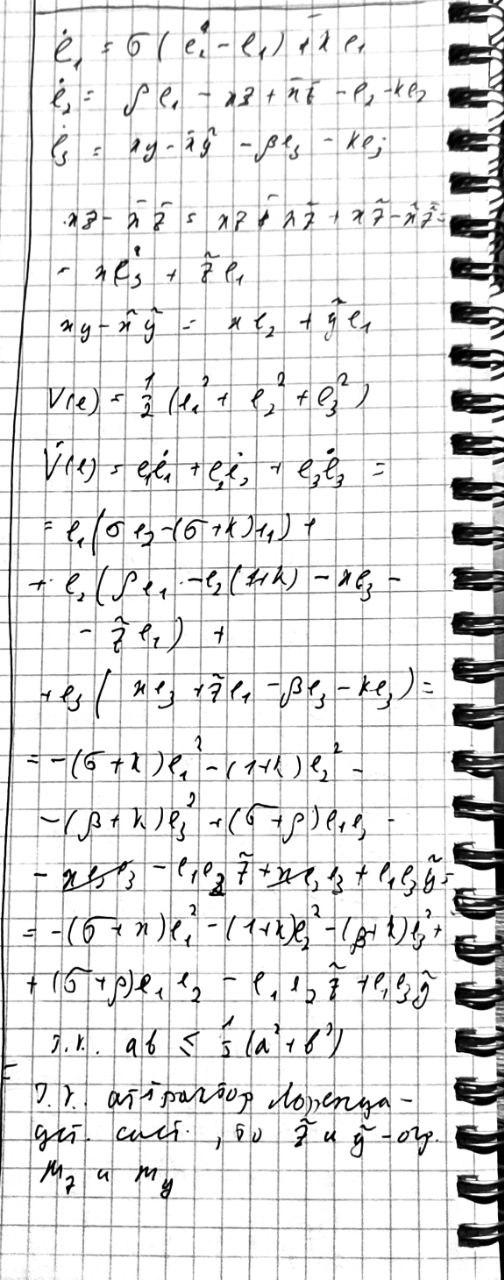

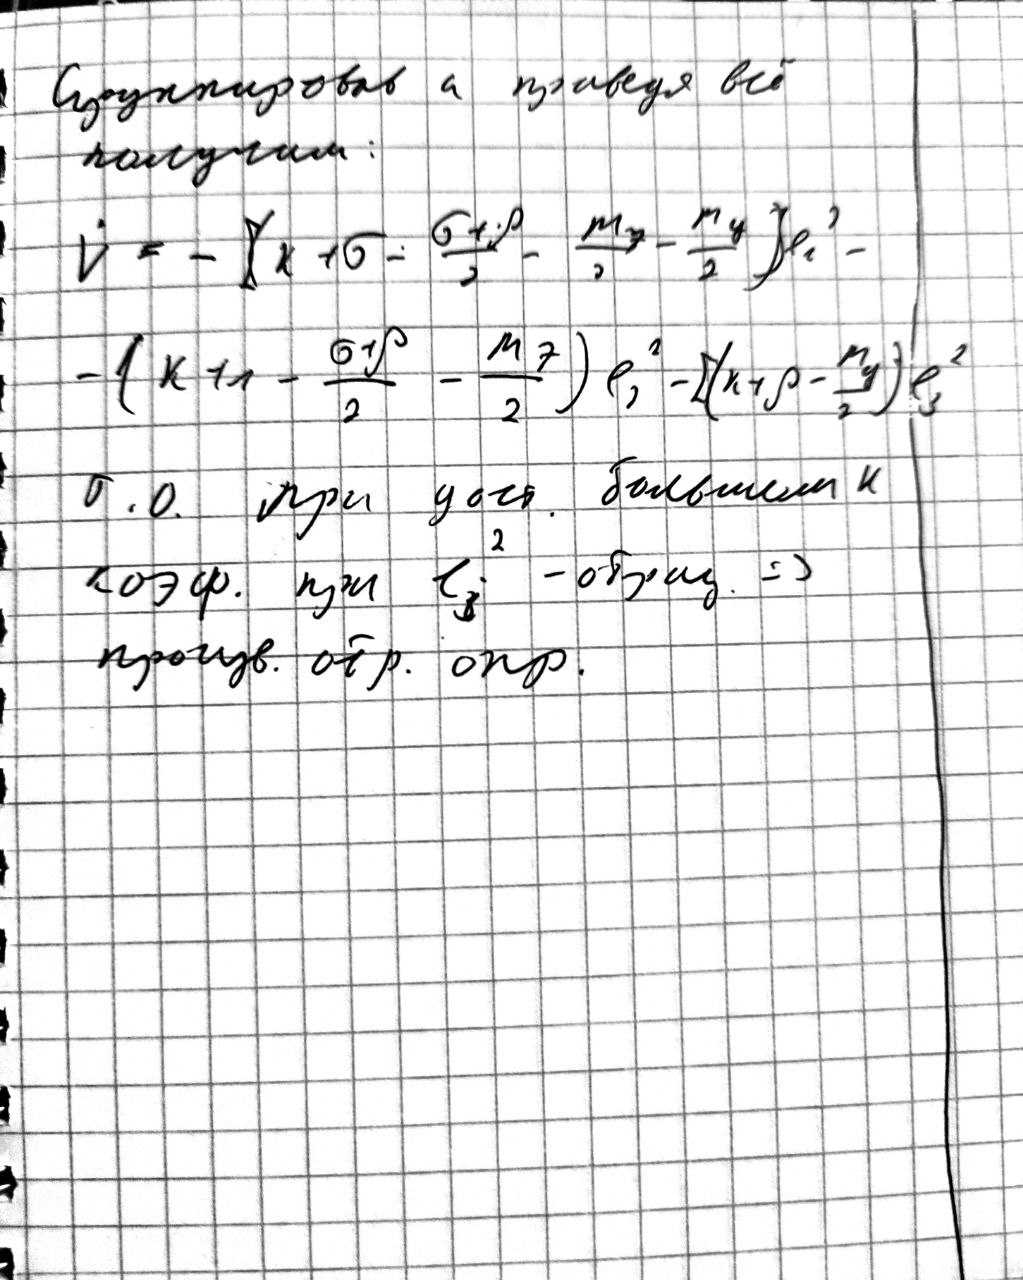

---
> ❗ **Место для Вашего аналитического решения** ❗

---


## Шифрование и дешифрование сообщения

Теперь реализуем это в коде. Пусть наше секретное сообщение — это низкочастотный гармонический сигнал: $m(t) = 2 \sin(5t)$.
На стороне передатчика мы маскируем его хаотическим сигналом $x(t)$, формируя передаваемый шифротекст:
$$C(t) = m(t) + x(t)$$

На стороне приемника, благодаря функции Ляпунова, мы знаем, что $\tilde{x}(t) \to x(t)$. Следовательно, дешифрованное сообщение можно получить как:
$$\tilde{m}(t) = C(t) - \tilde{x}(t)$$


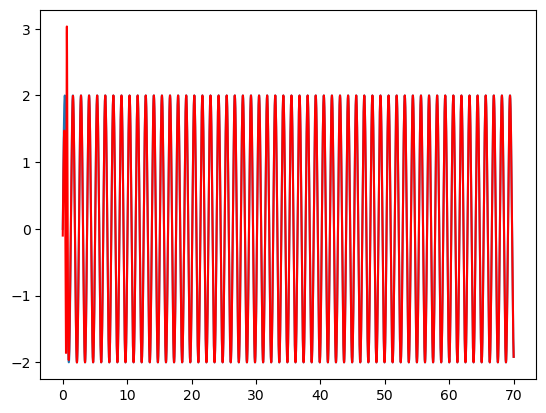

In [79]:
def coupled_system(t, state):
    x, y, z, xt, yt, zt = state
    
    # ===== ВАШ КОД ЗДЕСЬ (Система передатчика) =====
    dx = sigma*(y-x)
    dy = x*(rho - z) - y
    dz = x*y - beta*z
    
    # Передаваемый сигнал
    #u = 5*np.sin(t)
    k = 2
    
    # ===== ВАШ КОД ЗДЕСЬ (Система приемника с регулятором) =====
    dxt = sigma*(yt-xt) - k*(xt-x) 
    dyt = xt*(rho - zt) - yt - k*(yt-y)
    dzt = xt*yt - beta*zt - k*(zt-z)
    
    return [dx, dy, dz, dxt, dyt, dzt]

t_max = 70 
t_eval = np.linspace(0, t_max, 10000)

state0 = [0.1, 0, 0, 0.2, 0, 0]
t_span = [0, t_max]

sol = solve_ivp(coupled_system, t_span, state0, t_eval=t_eval, method='Radau',
                rtol=1e-6, 
                atol=1e-9)

x_values = sol.y[0]
xt_values = sol.y[3]

m = 2*np.sin(5*t_eval)

C = m + x_values
mt = C - xt_values

plt.plot(t_eval, m)
plt.plot(t_eval, mt, color="red")

---
> ❗ **Вопрос** ❗
>
> *Объясните, почему в первые доли секунды расшифрованное сообщение искажено, а затем становится идеальным? Как это связано с вашей функцией Ляпунова $V(e)$?*
>
> ***Ваш ответ:*** 
>
> 
---


# Третья часть

В теории динамических систем хаос измеряется строго с помощью спектра показателей Ляпунова. Они определяют экспоненциальную скорость расхождения бесконечно близких фазовых траекторий:
$$\|\delta x(t)\| \approx \|\delta x(0)\| e^{\lambda t}$$

Если старший показатель Ляпунова $\lambda_1 > 0$, система экспоненциально разводит близкие траектории, что является критерием детерминированного хаоса. Для вычисления изменения возмущения $\delta x(t)$ необходимо линеаризовать систему вдоль фазовой траектории, получив уравнение в вариациях:
$$\dot{\delta x} = J(x(t)) \delta x$$
где $J(x(t))$ — матрица Якоби исходной системы.


## Вычисление старшего показателя Ляпунова

Заполните функцию вычисления матрицы Якоби и запустите интегратор расширенной системы.


In [70]:
def lorenz_jacobian(x, y, z):
    """
    Матрица Якоби для системы Лоренца.
    """
    J = np.zeros((3, 3))
    # ===== ВАШ КОД ЗДЕСЬ (Заполните Якобиан) =====
    return J

def lorenz_extended(t, state):
    x, y, z = state[:3]
    pert = state[3:] # вектор возмущения
    
    # Исходная динамика
    # ===== ВАШ КОД ЗДЕСЬ =====
    dx, dy, dz = 0, 0, 0
    
    # Уравнение в вариациях
    # J = lorenz_jacobian(x, y, z)
    # dpert = ...
    dpert = [0, 0, 0]
    
    return np.concatenate(([dx, dy, dz], dpert))

# Начальное состояние и единичное возмущение по оси x
state0 = ...
t_eval = ...

sol = ...

# Вычисление старшего показателя Ляпунова (LLE) в динамике
# perturbation_magnitudes = ...
# lyapunov_exponents = ...

# Постройте график сходимости lyapunov_exponents


# Четвертая часть


## Уравнение и описание

Представьте, что вы хотите описать распространение сигнала в среде, где одновременно действуют два процесса: **диффузия** и **реакция**. Это описывается **уравнением реакции-диффузии**:  
$$  
u_t = D u_{xx} + f(u),  
$$  
где:  
- $ u(t, x) $ — амплитуда сигнала в точке $ x $ и момент времени $ t $.  
- $ D $ — коэффициент диффузии, определяющий скорость рассеяния сигнала.  
- $ f(u) $ — функция реакции, которая может создавать **стационарные решения** — точки равновесия системы.  

>**Определение стационарного решения**:  
>Это решение $ u(x) $, которое не зависит от времени ($ u_t = 0 $), то есть удовлетворяет уравнению:  
>$$  
>0 = D u_{xx} + f(u).  
>$$  
Независимо от начального условия, система сойдётся к этим решениям через время.  

В криптографии его используют для генерации **непредсказуемых ключей**, основанных на хаотической динамике. Например, если выбрать $ f(u) = u - u^3 $, то стационарные решения $ u = \pm 1 $ становятся аттракторами.*Почему хаос и устойчивость одновременно полезны для шифрования?* Хаос создает непредсказуемые ключи, а устойчивость обеспечивает, что ключ можно восстановить, даже если среда передачи добавляет шум.  

---

## Численное решение: что нужно сделать?  

Ваша задача — реализовать уравнение $ u_t = D u_{xx} + u - u^3 $ с помощью метода **конечных разностей**. Вот как это сделать:  

1. **Дискретизация пространства и времени**:  
   - Разбейте пространство на точки с шагом $ \Delta x $. Например, если длина области $ L = 100 $, а $ \Delta x = 0.5 $, то общее количество точек $ N_x = L/\Delta x = 200 $.  
   - Разбейте время на шаги $ \Delta t $, например, $ \Delta t = 0.01 $.  

2. **Начальное условие**:  
   Задайте начальное состояние $ u(0, x) $, например, прямоугольный импульс в центре:  
   $$  
   u(0, x) = \begin{cases}  
   1, & \text{в центре}, \\  
   0, & \text{вокруг}.  
   \end{cases}  
   $$  
   Это имитирует "сигнал", который будет эволюционировать в аттракторы.  

3. **Итерационный процесс**:  
   В каждом временном шаге обновляйте значения $ u $ с помощью формулы:  
   $$  
   u^{n+1}_i = u^n_i + \Delta t \left( D \frac{u^n_{i+1} - 2u^n_i + u^n_{i-1}}{(\Delta x)^2} + u^n_i - (u^n_i)^3 \right).  
   $$  
   Здесь:  
   - Диффузия $ D u_{xx} $ моделирует рассеяние сигнала.  
   - Реакция $ f(u) = u - u^3 $ "тянет" значения $ u $ к аттракторам $ \pm 1 $.  


In [71]:
def reaction_diffusion(D: float, L: int, T: int, dx: float, dt: float) -> np.ndarray:
    Nx = int(L / dx)
    Nt = int(T / dt)
    u = np.zeros((Nt, Nx))
    
    # Начальное условие: небольшой импульс в центре
    u[0, Nx//2 - 5 : Nx//2 + 5] = 1.0
    
    # Нелинейная функция реакции f(u) = u - u^3
    def f(u_val):
        # ===== ВАШ КОД ЗДЕСЬ =====
        return 0

    for n in range(0, Nt - 1):
        for i in range(1, Nx - 1):
            # ===== ВАШ КОД ЗДЕСЬ (Шаг интегрирования, схема Эйлера) =====
            pass
        # Периодические граничные условия
        # ===== ВАШ КОД ЗДЕСЬ =====
        pass
        
    return u

# u_signal = ...

# Выведите результат с помощью plt.imshow


---
> ❗ **Вопрос** ❗
>
> Что произойдет, если график $ V(t) $ будет расти?
>
>
> 
---

In [72]:
def lyapunov_function(u, D: float, dx: float) -> float:
    # u: массив значений в фиксированный момент времени 
    # Вычислим аналог функции Ляпунова (энергии) для реакции-диффузии
    # ===== ВАШ КОД ЗДЕСЬ =====
    return 0

# V_t = ...

# Постройте график Динамики функции Ляпунова


---
> ❗ **Вопрос** ❗
>
> Почему в качестве ключа стоит использовать промежуточное состояние $ u(t_{mid},x) $ (где $0 < t < T$), а не начальное $ u(0,x) $ или финальное $ u(T,x) $?
>
>
> 
---

In [73]:
import hashlib

# ===== Выбор начального условия =====
N_space = ...
L_domain = ...
D_coef = ...
dx = ...
dt = ...
T_total = ...
Nt = ...
x = ...

u = ...

# ===== ВАШ КОД ЗДЕСЬ (Установите свое начальное условие u[0, :]) =====


# Функции реакции
def f_react(v): return ...


# ===== Анализ u(x, t) в разные моменты =====
# Постройте графики для разных моментов времени
# times_to_plot = [0, Nt//4, Nt//2, 3*Nt//4, Nt-1]


def generate_key_from_PDE(u_signal: np.ndarray, t_index: int, key_length: int) -> int:
    """
    u_signal : 2D массив (Nt x Nx)
    t_index  : индекс момента времени
    key_length: длина ключа в байтах
    """
    # ===== ВАШ КОД ЗДЕСЬ =====
    hash_val = "0"
    return int(hash_val[:16], 16) if hash_val else 0

# Выберите переходный режим
# t_key_idx = ...
# key_pde = generate_key_from_PDE(u, t_key_idx, 16)


---
> ❗ **Вопрос** ❗
>
> *Проанализируйте графики $u(x, t)$ в разные моменты времени:*
> 1. *Почему $u(0, x)$ — плохой ключ? А финальное $u(T, x)$?*
> 2. *Какой диапазон времён вы выбрали для ключа и почему?*
>
> ***Ваш ответ:*** 
>
> 
---


---
> ❗ **Вопрос** ❗
>
> Как хаотический ключ повышает безопасность по сравнению с случайным ключом?
>
>
> 
---

In [74]:
def encrypt(text: str, key: int) -> str:
    # ===== ВАШ КОД ЗДЕСЬ =====
    pass

# Осуществите шифрование с PDE ключем
# ciphertext_pde = encrypt(plaintext, key_pde)


---
> ❗ **Вопрос** ❗
>
> Как устойчивость системы (анализ через функцию Ляпунова) влияет на расшифровку?
>
>
> 
---

In [75]:
def decrypt(ciphertext: str, key: int) -> str:
    # ===== ВАШ КОД ЗДЕСЬ =====
    pass

# Осуществите расшифрование с PDE ключем
# decrypted_pde = decrypt(ciphertext_pde, key_pde)


In [76]:
ciphertext = encrypt(plaintext, key_pde)
decrypted_text = decrypt(ciphertext, key_pde)

print("Исходный текст:", plaintext)
print("Расшифрованный текст:", decrypted_text)


NameError: name 'key_pde' is not defined

---
> ❗ **Вопрос** ❗
>
> 1. Что произойдет с графиком $ V(t) $, если начальное условие сильно отличается от аттракторов?
> 2. Почему стационарное решение имеет значения $ \pm 1 $?
> 3. Как форма графика $ u(T,x) $ влияет на выбор параметра $ D $?
>
>
> 
---